# Doublet analysis (scDblFinder) CLL/MBL

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(ggplot2)
library(Seurat)
library(scDblFinder)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.3.6      ✔ purrr   0.3.4 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.4.1 
✔ readr   2.1.2      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Attaching SeuratObject



In [2]:
suppressMessages(source("code/functions.R"))

### Load expression data

In [3]:
# Q1 <- readRDS("output/Q1_SCT.rds") 
# Q2 <- readRDS("output/Q2_SCT.rds")

### Load df with filtered SHMss events (trully positive)

In [4]:
df_summary <- read.csv("output/df_summary_CLL_MBL_v1.csv")
head(df_summary)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,Q1_S9121-LC,TCGTACCCACTTCGAA,8,A,CC.GA,FR1,A-G,19-5,TRUE
2,Q1_S9121-LC,TCGTACCCACTTCGAA,30,C,TC.CT,FR1,A-C,5-19,TRUE
3,Q1_S9121-LC,TCGTACCCACTTCGAA,31,C,CC.TG,FR1,C-T,19-5,TRUE
4,Q1_S9121-LC,TCGTACCCACTTCGAA,33,G,CT.TC,FR1,C-G,5-19,TRUE
5,Q1_S9121-LC,TCGTACCCACTTCGAA,43,G,CT.TA,FR1,A-G,5-19,TRUE
6,Q1_S9121-LC,TCGTACCCACTTCGAA,44,T,TG.AG,FR1,C-T,5-19,TRUE


## Run scDblFinder

In [5]:
# sce_q1 <- scDblFinder(as.SingleCellExperiment(Q1))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_q1 <- as.data.frame(sce_q1@colData) 

# table(sce_q1$scDblFinder.class)

In [6]:
# sce_q2 <- scDblFinder(as.SingleCellExperiment(Q2))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_q2 <- as.data.frame(sce_q2@colData) 

# table(sce_q2$scDblFinder.class)

In [7]:
# dou_CLL <- bind_rows(dbl_q1 ,dbl_q2) %>% 
#                select(ident,scDblFinder.class, scDblFinder.score,nCount_RNA,nFeature_RNA) %>%
#                rownames_to_column("cell") %>%
#                mutate(cell = gsub("-.*$", "", cell)) %>%
#                rename("experiment"="ident")
# head(dou_CLL)

In [8]:
# head(dou_CLL)
# write.csv(dou_CLL, "output/doublet_in_CLL_MBL.csv",row.names = FALSE)

In [9]:
#read doublet table
doublet <- read.csv("output/doublet_in_CLL_MBL.csv")

In [10]:
# number of doublet
table(doublet$scDblFinder.class)


doublet singlet 
    825   16122 

In [11]:
# add doublet information to df
ft <-df_summary %>% mutate(experiment = str_sub(subject, 1, 2)) %>% left_join(doublet %>% select(cell,experiment,scDblFinder.class, scDblFinder.score,nCount_RNA,nFeature_RNA),c("cell","experiment")) 
head(ft)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<int>,<int>
1,Q1_S9121-LC,TCGTACCCACTTCGAA,8,A,CC.GA,FR1,A-G,19-5,TRUE,Q1,singlet,0.0008805199,3388,920
2,Q1_S9121-LC,TCGTACCCACTTCGAA,30,C,TC.CT,FR1,A-C,5-19,TRUE,Q1,singlet,0.0008805199,3388,920
3,Q1_S9121-LC,TCGTACCCACTTCGAA,31,C,CC.TG,FR1,C-T,19-5,TRUE,Q1,singlet,0.0008805199,3388,920
4,Q1_S9121-LC,TCGTACCCACTTCGAA,33,G,CT.TC,FR1,C-G,5-19,TRUE,Q1,singlet,0.0008805199,3388,920
5,Q1_S9121-LC,TCGTACCCACTTCGAA,43,G,CT.TA,FR1,A-G,5-19,TRUE,Q1,singlet,0.0008805199,3388,920
6,Q1_S9121-LC,TCGTACCCACTTCGAA,44,T,TG.AG,FR1,C-T,5-19,TRUE,Q1,singlet,0.0008805199,3388,920


In [12]:
# number of doublet
table(ft$scDblFinder.class)


singlet 
     16 

In [13]:
# add info about scSHM to doblet data for plotting
doublet <-  doublet %>%
                mutate(SHMa_pos=ifelse(cell %in% df_summary$cell, "Yes","No")) 

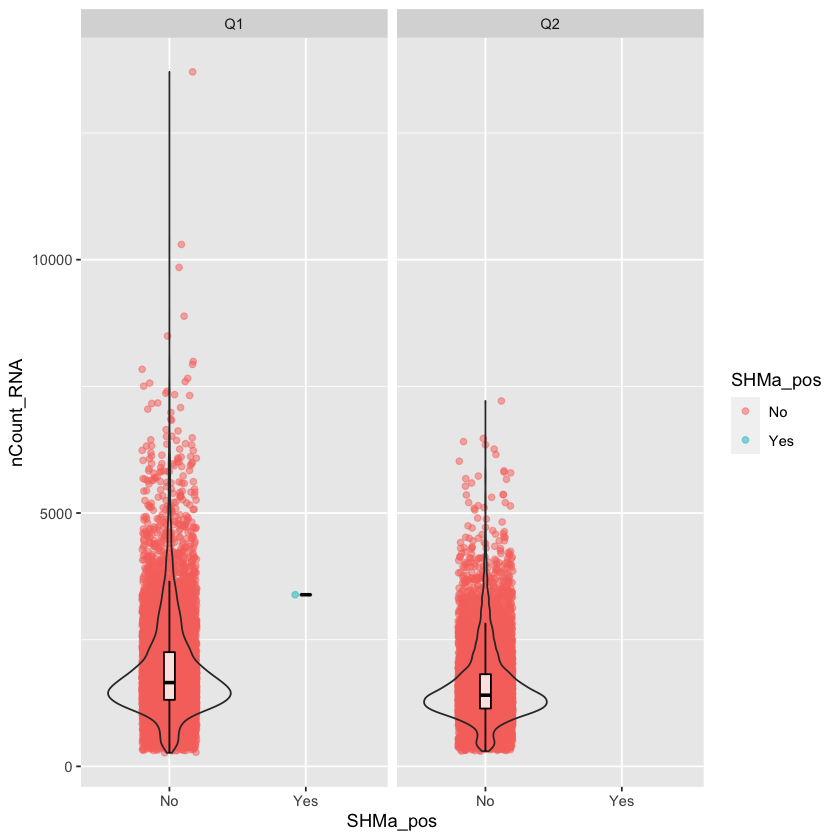

In [14]:
raw_con <- ggplot(doublet, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = SHMa_pos),position = position_jitterdodge(seed = 1, dodge.width = 0.9), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment) 

fig_save(raw_con, filename = "figs/FL/raw_counts_SHM_events_K45678", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con

In [15]:
# are the distribution different?
res <- wilcox.test(nCount_RNA ~ SHMa_pos, data = doublet,
                   exact = FALSE)
res


	Wilcoxon rank sum test with continuity correction

data:  nCount_RNA by SHMa_pos
W = 873, p-value = 0.1203
alternative hypothesis: true location shift is not equal to 0


In [16]:
#perform Kolmogorov-Smirnov test (check if the distribution are different)
ks.test(doublet$nCount_RNA[doublet$SHMa_pos == "Yes"], doublet$nCount_RNA[doublet$SHMa_pos == "No"])


	Two-sample Kolmogorov-Smirnov test

data:  doublet$nCount_RNA[doublet$SHMa_pos == "Yes"] and doublet$nCount_RNA[doublet$SHMa_pos == "No"]
D = 0.94848, p-value = 0.3294
alternative hypothesis: two-sided


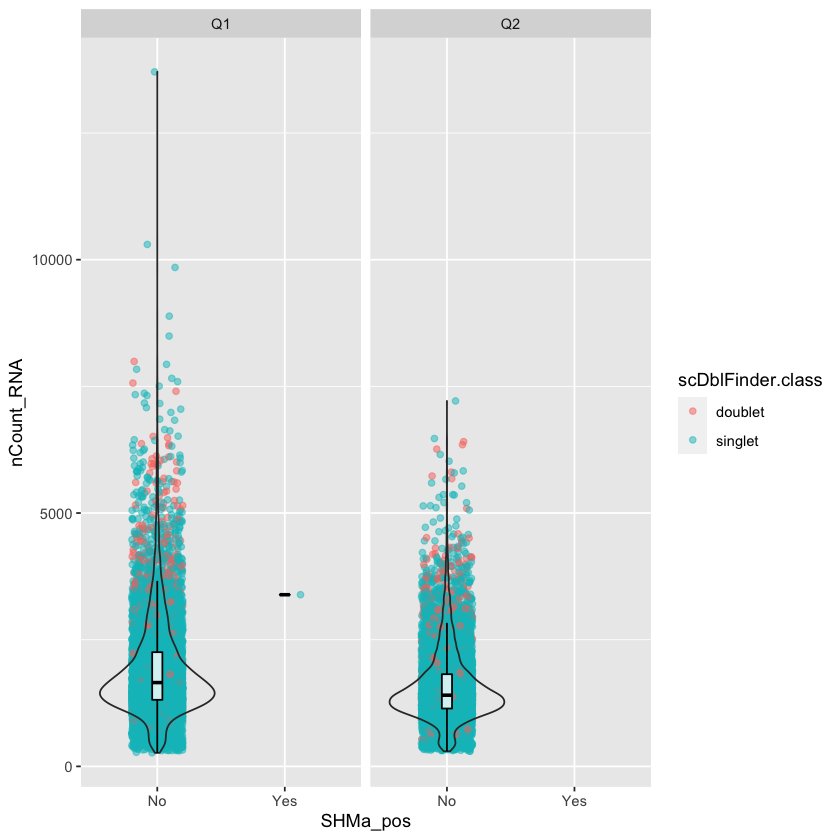

In [17]:
raw_con <- ggplot(doublet, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = scDblFinder.class),position = position_jitterdodge(seed = 2, dodge.width = 0), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment)

fig_save(raw_con, filename = "figs/FL/raw_RNA_counts_SHM_events_scDblFinder_K45678", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con